# DI 501 Term Project — Phase 1 Data Exploration

**Dataset:** SpotGenTrack Popularity Dataset (SPD) 
**Author:** Furkan Turac

This notebook performs the data-quality checks and descriptive statistics
reported in the Phase 1 paper, evaluates the naive classification baseline
for RQ1, and produces the group summary that will feed the RQ2 hypothesis
test in Phase 2.

Only the Spotify audio and metadata tables are used — the Genius-derived
lyric table is intentionally excluded from this project.

## 1. Setup and configuration

In [24]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, make_scorer

warnings.filterwarnings('ignore', category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(context='paper', style='whitegrid', font_scale=0.9)

## 2. Locate and load SPD tables

In [25]:
tracks_path  = "./data/raw/spotify_tracks.csv"
artists_path = "./data/raw/spotify_artists.csv"

tracks  = pd.read_csv(tracks_path,  low_memory=False)
artists = pd.read_csv(artists_path, low_memory=False)

print('\ntracks  shape :', tracks.shape)
print('artists shape :', artists.shape)
print('\ntracks  columns :', list(tracks.columns))
print('\nartists columns :', list(artists.columns))


tracks  shape : (101939, 32)
artists shape : (56129, 9)

tracks  columns : ['Unnamed: 0', 'acousticness', 'album_id', 'analysis_url', 'artists_id', 'available_markets', 'country', 'danceability', 'disc_number', 'duration_ms', 'energy', 'href', 'id', 'instrumentalness', 'key', 'liveness', 'loudness', 'lyrics', 'mode', 'name', 'playlist', 'popularity', 'preview_url', 'speechiness', 'tempo', 'time_signature', 'track_href', 'track_name_prev', 'track_number', 'uri', 'valence', 'type']

artists columns : ['Unnamed: 0', 'artist_popularity', 'followers', 'genres', 'id', 'name', 'track_id', 'track_name_prev', 'type']


## 3. Data Quality Checks

### 3.1 Completeness — missing values per column

In [26]:
def missingness_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Return a per-column missingness report sorted by missing fraction.

    Shows ALL columns (even 0-missing) so an all-clean table is visible
    instead of appearing empty.
    """
    n = len(df)
    miss = df.isna().sum()
    rep = pd.DataFrame({
        'missing_count': miss,
        'missing_pct'  : (miss / n * 100).round(2),
    }).sort_values('missing_pct', ascending=False)
    print(f'--- {name}: {n:,} rows, {df.shape[1]} columns ---')
    print(f'    total missing cells: {int(miss.sum()):,}')
    return rep

missingness_report(tracks, 'tracks')
missingness_report(artists, 'artists')

--- tracks: 101,939 rows, 32 columns ---
    total missing cells: 0
--- artists: 56,129 rows, 9 columns ---
    total missing cells: 1


,missing_count,missing_pct
Unnamed: 0,0,0.0
artist_popularity,0,0.0
followers,0,0.0
genres,0,0.0
id,0,0.0
name,1,0.0
track_id,0,0.0
track_name_prev,0,0.0
type,0,0.0


### 3.2 Uniqueness

In [27]:
id_col = next((c for c in ['id', 'track_id', 'spotify_id'] if c in tracks.columns), None)
if id_col:
    print(f'Duplicate Spotify track ids ({id_col}) :',
          int(tracks.duplicated(subset=[id_col]).sum()))
else:
    print('No obvious id column found in tracks')

dup_key = [c for c in ['name', 'artists_id', 'artist_id', 'duration_ms']
           if c in tracks.columns]
if dup_key:
    print(f'Duplicate by {dup_key} :',
          int(tracks.duplicated(subset=dup_key).sum()))

Duplicate Spotify track ids (id) : 0
Duplicate by ['name', 'artists_id', 'duration_ms'] : 2438


### 3.3 Validity

In [28]:
# Expected bounds according to Spotify Web API documentation
VALID_BOUNDS = {
    'danceability'    : (0.0,   1.0),
    'energy'          : (0.0,   1.0),
    'valence'         : (0.0,   1.0),
    'acousticness'    : (0.0,   1.0),
    'instrumentalness': (0.0,   1.0),
    'liveness'        : (0.0,   1.0),
    'speechiness'     : (0.0,   1.0),
    'loudness'        : (-60.0, 0.0),   
    'tempo'           : (0.0,   250.0),  
    'popularity'      : (0,     100), 
}

def range_violations(df: pd.DataFrame, bounds: dict) -> pd.DataFrame:
    """Count rows outside the documented range for each feature."""
    rows = []
    for col, (lo, hi) in bounds.items():
        if col not in df.columns:
            continue
        s = df[col]
        rows.append({
            'feature'  : col,
            'lo_bound' : lo,
            'hi_bound' : hi,
            'below_lo' : int((s < lo).sum()),
            'above_hi' : int((s > hi).sum()),
            'min_seen' : s.min(),
            'max_seen' : s.max(),
        })
    return pd.DataFrame(rows)

range_violations(tracks, VALID_BOUNDS)

,feature,lo_bound,hi_bound,below_lo,above_hi,min_seen,max_seen
0,danceability,0.0,1.0,0,0,0.0,0.989
1,energy,0.0,1.0,0,0,0.0,1.000
2,valence,0.0,1.0,0,0,0.0,0.993
3,acousticness,0.0,1.0,0,0,0.0,0.996
4,instrumentalness,0.0,1.0,0,0,0.0,1.000
5,liveness,0.0,1.0,0,0,0.0,0.999
6,speechiness,0.0,1.0,0,0,0.0,0.969
7,loudness,-60.0,0.0,0,42,-60.0,2.719
8,tempo,0.0,250.0,0,0,0.0,244.035
9,popularity,0.0,100.0,0,0,0.0,97.000


### 3.4 Descriptive statistics for the selected features


In [29]:
num_features = [
    'popularity', 'danceability', 'energy', 'valence',
    'acousticness', 'instrumentalness', 'speechiness', 'liveness',
    'loudness', 'tempo', 'duration_ms',
]
num_features = [c for c in num_features if c in tracks.columns]

desc = tracks[num_features].describe(percentiles=[0.25, 0.5, 0.75]).T
desc = desc[['mean', 'std', '50%', 'min', 'max']]
desc.columns = ['Mean', 'Std.Dev.', 'Median', 'Min', 'Max']
desc.round(2)

,Mean,Std.Dev.,Median,Min,Max
popularity,39.78,16.79,41.00,0.0,97.00
danceability,0.59,0.18,0.61,0.0,0.99
energy,0.59,0.26,0.63,0.0,1.00
valence,0.48,0.26,0.48,0.0,0.99
acousticness,0.35,0.33,0.24,0.0,1.00
instrumentalness,0.15,0.30,0.00,0.0,1.00
speechiness,0.13,0.20,0.05,0.0,0.97
liveness,0.20,0.18,0.12,0.0,1.00
loudness,-9.46,6.20,-7.60,-60.0,2.72
tempo,118.36,30.22,118.07,0.0,244.04


In [30]:
# Mode flag — share of tracks in major vs. minor key
if 'mode' in tracks.columns:
    major_share = (tracks['mode'] == 1).mean() * 100
    print(f'Major-key (mode=1) tracks: {major_share:.2f}% of the dataset')
    print(tracks['mode'].value_counts(dropna=False))

Major-key (mode=1) tracks: 61.82% of the dataset
mode
1.0    63014
0.0    38925
Name: count, dtype: int64


## 4. Target construction — three popularity tiers (RQ1)

In [31]:
# Drop rows without a popularity label (cannot be targets)
clean = tracks.dropna(subset=['popularity']).copy()

t1, t2 = np.quantile(clean['popularity'], [1/3, 2/3])
print(f'Tertile cut-points: t1={t1:.2f}, t2={t2:.2f}')
print(f'N after dropping missing popularity: {len(clean):,}')

def to_tier(x: float) -> str:
    """Map a continuous popularity score to Low / Medium / High."""
    if x < t1:
        return 'Low'
    if x < t2:
        return 'Medium'
    return 'High'

clean['pop_tier'] = clean['popularity'].apply(to_tier)
print('\nClass distribution:')
print(clean['pop_tier'].value_counts(normalize=True).round(3))

Tertile cut-points: t1=33.00, t2=48.00
N after dropping missing popularity: 101,939

Class distribution:
pop_tier
Medium    0.342
High      0.337
Low       0.321
Name: proportion, dtype: float64


## 5. Popularity distribution figure (Figure 1 of the paper)

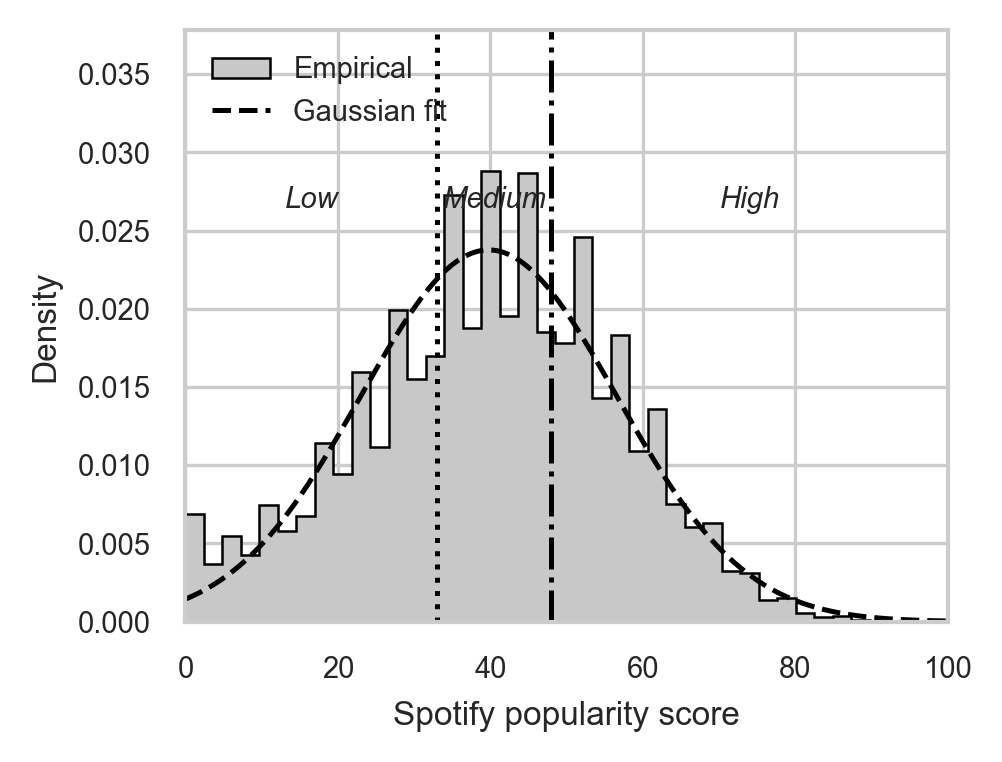

Saved figure to C:\Users\furka\OneDrive\Desktop\to_odtuclass\di501_project_phase1_replication\di501_project\reports\figures/popularity_distribution.pdf


In [33]:
from scipy.stats import norm

PROJECT_ROOT = Path.cwd().resolve()
FIG_DIR      = PROJECT_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(3.4, 2.6), dpi=300)

ax.hist(clean['popularity'], bins=40, density=True,
        histtype='stepfilled', facecolor='#c8c8c8',
        edgecolor='black', linewidth=0.6, label='Empirical')

mu, sigma = clean['popularity'].mean(), clean['popularity'].std()
x = np.linspace(0, 100, 400)
ax.plot(x, norm.pdf(x, mu, sigma), color='black',
        linestyle='--', linewidth=1.2, label='Gaussian fit')

ax.axvline(t1, color='black', linestyle=':',  linewidth=1.2)
ax.axvline(t2, color='black', linestyle='-.', linewidth=1.2)

ax.set_ylim(0, ax.get_ylim()[1] * 1.25)
ymax = ax.get_ylim()[1]
ax.text(t1 / 2,         ymax * 0.70, 'Low',    ha='center', fontsize=7, style='italic')
ax.text((t1 + t2) / 2,  ymax * 0.70, 'Medium', ha='center', fontsize=7, style='italic')
ax.text((t2 + 100) / 2, ymax * 0.70, 'High',   ha='center', fontsize=7, style='italic')

ax.set_xlabel('Spotify popularity score', fontsize=8)
ax.set_ylabel('Density',                   fontsize=8)
ax.set_xlim(0, 100)
ax.tick_params(axis='both', labelsize=7)
ax.legend(fontsize=7, loc='upper left', frameon=False)

plt.tight_layout()
fig.savefig(FIG_DIR / 'popularity_distribution.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'popularity_distribution.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved figure to {FIG_DIR}/popularity_distribution.pdf')

## 6. Naive baseline (Step 4 of the guideline)

- **Majority-class** (`strategy='most_frequent'`): always predicts the most frequent tier.
- **Stratified** (`strategy='stratified'`): draws predictions from the class prior.

Both are evaluated with **Macro-F1** and **Balanced Accuracy** under stratified 5-fold CV.

In [34]:
# Baselines don't look at X, so a placeholder matrix with the right shape is enough.
y = clean['pop_tier'].values
X = np.zeros((len(y), 1))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def eval_baseline(strategy: str) -> dict:
    clf = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    f1 = cross_val_score(clf, X, y, cv=cv,
                         scoring=make_scorer(f1_score, average='macro'))
    ba = cross_val_score(clf, X, y, cv=cv, scoring='balanced_accuracy')
    return {
        'strategy'      : strategy,
        'macro_f1_mean' : f1.mean(),
        'macro_f1_std'  : f1.std(ddof=1),
        'bal_acc_mean'  : ba.mean(),
        'bal_acc_std'   : ba.std(ddof=1),
    }

pd.DataFrame([
    eval_baseline('most_frequent'),
    eval_baseline('stratified'),
]).round(4)

,strategy,macro_f1_mean,macro_f1_std,bal_acc_mean,bal_acc_std
0,most_frequent,0.1700,0.0000,0.3333,0.0000
1,stratified,0.3368,0.0029,0.3368,0.0029


## 7. Preliminary view of RQ2 (major vs. minor key popularity)

In [35]:
if 'mode' in clean.columns:
    grp = clean.groupby(clean['mode'].astype(int))['popularity']
    summary = grp.agg(n='count', mean='mean', std='std', median='median').round(2)
    summary.index = summary.index.map({1: 'mode=1 (major)', 0: 'mode=0 (minor)'})
    display(summary)

,n,mean,std,median
mode,,,,
mode=0 (minor),38925,40.00,16.66,41.0
mode=1 (major),63014,39.65,16.87,40.0
